# Eval Metric Scale
Runs the v2 SLAT-conditioned metric scale checkpoint on the 64 held-out samples and displays predictions alongside ground truth as they come in.

In [4]:
from __future__ import annotations

import os
from collections import defaultdict
from pathlib import Path

os.environ.setdefault("LIDRA_SKIP_INIT", "1")
os.environ.setdefault("ATTN_BACKEND", "sdpa")
os.environ.setdefault("SPARSE_ATTN_BACKEND", "sdpa")
import sys
sys.path.append("/mnt/source/sam-3d-objects/")
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.notebook import tqdm

from sam3d_objects.data.dataset.metric.nocs import OmniNOCSReal275Dataset
from sam3d_objects.model.backbone.metric_scale_decoder import MetricScaleDecoder
from sam3d_objects.model.backbone.scale_head import (
    MetricScaleHead,
    _ScaleAugmentedEmbedderProxy,
    extract_ss_scale_features,
)
from sam3d_objects.training.finetune_metric_scale import (
    freeze_pipeline,
    load_metric_checkpoint,
    make_train_eval_subsets,
)

In [7]:
# ── Config ────────────────────────────────────────────────────────────────
CHECKPOINT  = "/mnt/source/sam-3d-objects/artifacts/metric_scale/checkpoints/nocs_sceneholdout_slat_conditioned_v2_best.pt"
CONFIG      = "/mnt/source/sam-3d-objects/checkpoints/hf/pipeline.yaml"
ANNOTATIONS = "/mnt/source/datasets_sam3d/OmniNOCS/omninocs_release_nocs_real275"
RGB_ROOT    = "/mnt/source/datasets_sam3d/OmniNOCS/real_test"
SPLIT       = "train"
DEVICE      = "cuda"

HELDOUT_SAMPLES = 64   # last 64 records in record-group order — matches training held-out
SEED             = 0
SPLIT_GROUP      = "record"

STAGE1_STEPS = 4
STAGE2_STEPS = 12
MIN_MASK_PX  = 500
INJECT_SCALE = True

In [8]:
from hydra.utils import instantiate
from omegaconf import OmegaConf

print(f"Loading pipeline from {CONFIG} ...")
config = OmegaConf.load(CONFIG)
config.workspace_dir = str(Path(CONFIG).resolve().parent)
config.compile_model = False
config.device = DEVICE
pipeline = instantiate(config)
freeze_pipeline(pipeline)

scale_head    = MetricScaleHead().to(DEVICE).eval()
scale_decoder = MetricScaleDecoder().to(DEVICE).eval()

try:
    slat_backbone = pipeline.models["slat_generator"].reverse_fn.backbone
except (AttributeError, KeyError):
    slat_backbone = None
    print("Warning: could not locate slat_generator backbone — cross-attn weights not restored")

load_metric_checkpoint(CHECKPOINT, scale_head, scale_decoder, slat_backbone)
print(f"Checkpoint loaded: {CHECKPOINT}")

Loading pipeline from /mnt/source/sam-3d-objects/checkpoints/hf/pipeline.yaml ...


2026-05-07 17:40:35.634 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:17 - GPU name is NVIDIA A100-SXM4-80GB


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-05-07 17:40:40.435 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functional.py:51: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functional.py:100: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functional.py:166: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functiona

[SPARSE][CONV] spconv algo: auto


2026-05-07 17:40:49.327 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-05-07 17:40:49.329 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-05-07 17:40:49.389 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
/opt/conda/envs/sam3d/lib/python3.11/site-packages/moge/model/v1.py:171: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
2026-05-07 17:41:06.648 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-05-07 17:41:06.653 | INFO     | sam3d_objects.pipeline.inference_pipeline:__ini

Restored SLAT cross-attn weights from /mnt/source/sam-3d-objects/artifacts/metric_scale/checkpoints/nocs_sceneholdout_slat_conditioned_v2_best.pt
Loaded metric scale checkpoint from /mnt/source/sam-3d-objects/artifacts/metric_scale/checkpoints/nocs_sceneholdout_slat_conditioned_v2_best.pt
Checkpoint loaded: /mnt/source/sam-3d-objects/artifacts/metric_scale/checkpoints/nocs_sceneholdout_slat_conditioned_v2_best.pt


In [9]:
full_dataset = OmniNOCSReal275Dataset(
    annotations_root=ANNOTATIONS,
    rgb_root=RGB_ROOT,
    split=SPLIT,
    min_mask_pixels=MIN_MASK_PX,
)
_, eval_dataset = make_train_eval_subsets(
    full_dataset,
    train_samples=0,
    heldout_samples=HELDOUT_SAMPLES,
    seed=SEED,
    shuffle_split=False,
    split_group=SPLIT_GROUP,
)
print(f"Full dataset: {len(full_dataset)} records")
print(f"Held-out eval set: {len(eval_dataset)} samples")

Split group=record train=16054 heldout=64
Full dataset: 16118 records
Held-out eval set: 64 samples


eval:   0%|          | 0/64 [00:00<?, ?it/s]

2026-05-07 18:05:18.824 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:668 - Sampling sparse structure: inference_steps=4, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-05-07 18:05:18.829 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:19.018 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Condition embedder finishes!
2026-05-07 18:05:19.834 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:718 - Downsampled coords from 13753 to 13672
2026-05-07 18:05:19.850 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:749 - Sampling sparse latent: inference_steps=12, strength=1, interval=[0, 500], rescale_t=1
2026-05-07 18:05:19.851 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:19.952 | INFO     | sam3d_

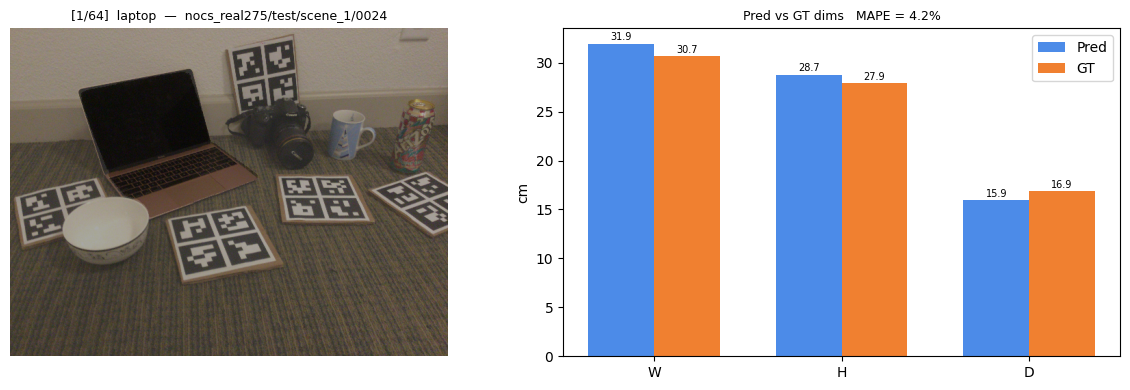

2026-05-07 18:05:24.604 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:668 - Sampling sparse structure: inference_steps=4, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-05-07 18:05:24.612 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:24.714 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Condition embedder finishes!
2026-05-07 18:05:25.439 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:718 - Downsampled coords from 12148 to 12076
2026-05-07 18:05:25.441 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:749 - Sampling sparse latent: inference_steps=12, strength=1, interval=[0, 500], rescale_t=1
2026-05-07 18:05:25.441 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:25.539 | INFO     | sam3d_

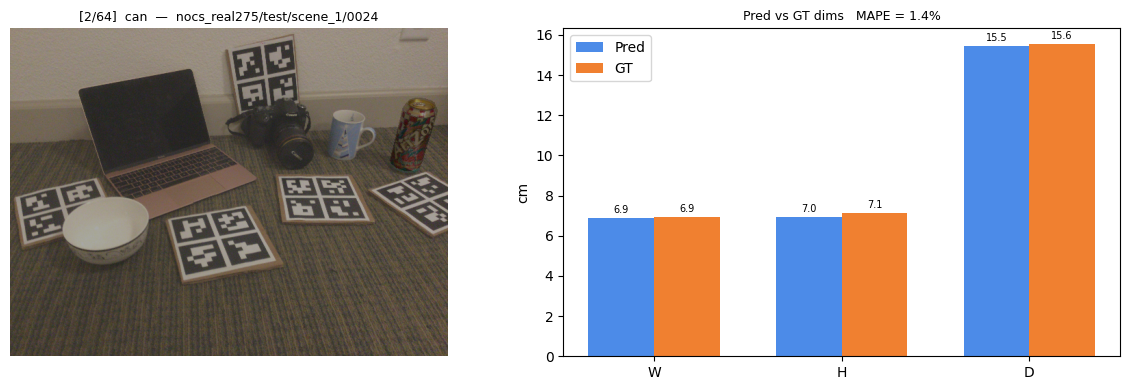

2026-05-07 18:05:28.949 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:668 - Sampling sparse structure: inference_steps=4, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-05-07 18:05:28.951 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:29.061 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Condition embedder finishes!
2026-05-07 18:05:29.824 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:718 - Downsampled coords from 34390 to 26065
2026-05-07 18:05:29.826 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:749 - Sampling sparse latent: inference_steps=12, strength=1, interval=[0, 500], rescale_t=1
2026-05-07 18:05:29.827 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:29.932 | INFO     | sam3d_

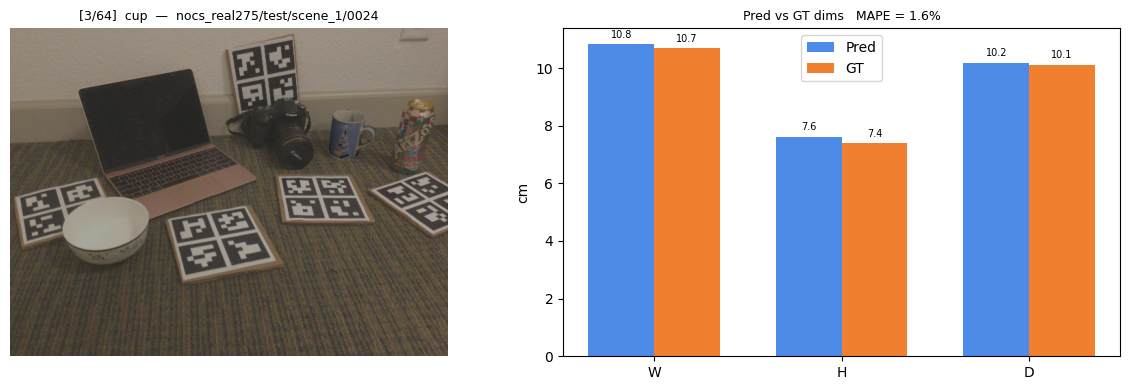

2026-05-07 18:05:35.464 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:668 - Sampling sparse structure: inference_steps=4, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-05-07 18:05:35.466 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:35.577 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Condition embedder finishes!
2026-05-07 18:05:36.317 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:718 - Downsampled coords from 21909 to 18906
2026-05-07 18:05:36.319 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:749 - Sampling sparse latent: inference_steps=12, strength=1, interval=[0, 500], rescale_t=1
2026-05-07 18:05:36.320 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:36.419 | INFO     | sam3d_

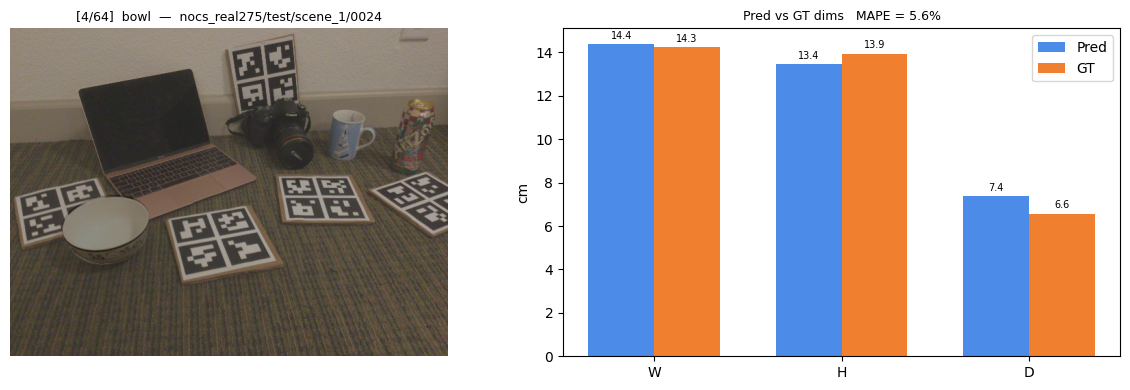

2026-05-07 18:05:41.693 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:668 - Sampling sparse structure: inference_steps=4, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-05-07 18:05:41.695 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:41.834 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Condition embedder finishes!
2026-05-07 18:05:42.661 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:718 - Downsampled coords from 35731 to 31136
2026-05-07 18:05:42.663 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:749 - Sampling sparse latent: inference_steps=12, strength=1, interval=[0, 500], rescale_t=1
2026-05-07 18:05:42.663 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:42.774 | INFO     | sam3d_

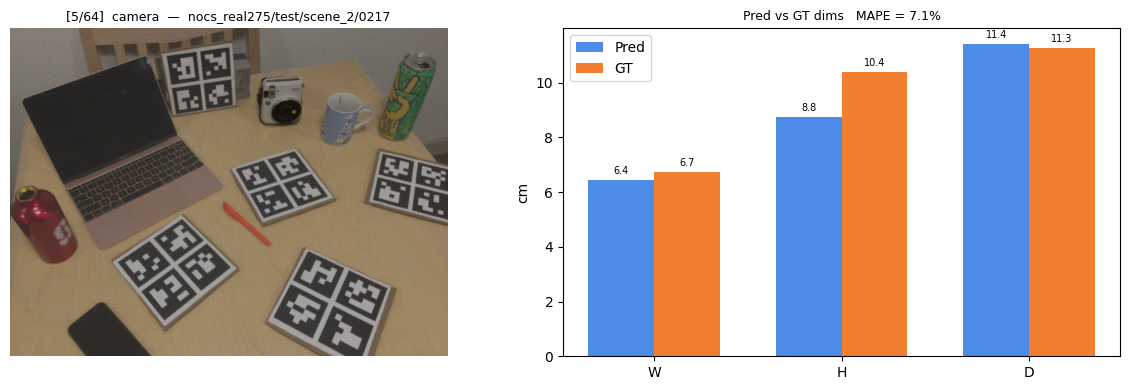

2026-05-07 18:05:49.571 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:668 - Sampling sparse structure: inference_steps=4, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-05-07 18:05:49.572 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:49.681 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Condition embedder finishes!
2026-05-07 18:05:50.404 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:718 - Downsampled coords from 9760 to 9749
2026-05-07 18:05:50.406 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:749 - Sampling sparse latent: inference_steps=12, strength=1, interval=[0, 500], rescale_t=1
2026-05-07 18:05:50.406 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:50.503 | INFO     | sam3d_ob

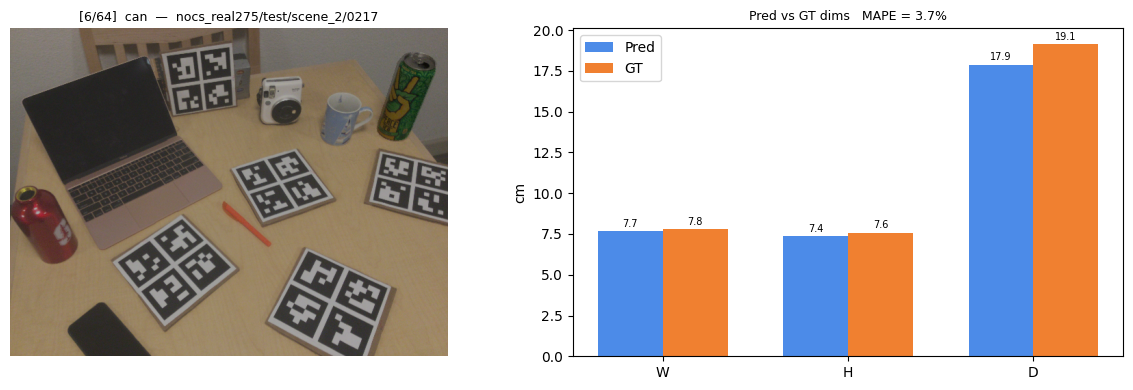

2026-05-07 18:05:54.431 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:668 - Sampling sparse structure: inference_steps=4, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-05-07 18:05:54.433 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:54.555 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Condition embedder finishes!
2026-05-07 18:05:55.292 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:718 - Downsampled coords from 38946 to 36348
2026-05-07 18:05:55.293 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:749 - Sampling sparse latent: inference_steps=12, strength=1, interval=[0, 500], rescale_t=1
2026-05-07 18:05:55.294 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-07 18:05:55.392 | INFO     | sam3d_

KeyboardInterrupt: 

In [10]:
@torch.no_grad()
def run_single(item):
    image = item["image"]
    with pipeline.device:
        pointmap  = pipeline.compute_pointmap(image)
        ss_input  = pipeline.preprocess_image(
            image, pipeline.ss_preprocessor, pointmap=pointmap["pointmap"]
        )
        slat_input = pipeline.preprocess_image(image, pipeline.slat_preprocessor)

        ss_out = pipeline.sample_sparse_structure(
            ss_input, inference_steps=STAGE1_STEPS, use_distillation=False
        )
        ss_scale_feats = extract_ss_scale_features(ss_out)
        if ss_scale_feats is not None:
            ss_scale_feats = ss_scale_feats.detach().to(pipeline.device)

        scale_token = scale_head(
            ss_out["shape"].detach(), ss_scale_feats,
            ss_input.get("pointmap_scale"), ss_input.get("pointmap_shift"),
        )

        orig_bb_emb = orig_ext_emb = slat_bb = None
        if INJECT_SCALE and hasattr(pipeline, "_get_slat_backbone"):
            tok = F.layer_norm(scale_token, [scale_token.shape[-1]]).detach()
            slat_bb = pipeline._get_slat_backbone()
            if slat_bb is not None:
                orig_bb_emb = slat_bb.condition_embedder
                slat_bb.condition_embedder = _ScaleAugmentedEmbedderProxy(orig_bb_emb, tok)
            cond_embs = getattr(pipeline, "condition_embedders", {})
            orig_ext_emb = cond_embs.get("slat_condition_embedder")
            if orig_ext_emb is not None:
                pipeline.condition_embedders["slat_condition_embedder"] = (
                    _ScaleAugmentedEmbedderProxy(orig_ext_emb, tok)
                )
        try:
            slat = pipeline.sample_slat(
                slat_input, ss_out["coords"],
                inference_steps=STAGE2_STEPS, use_distillation=False, with_grad=False,
            )
        finally:
            if slat_bb is not None and orig_bb_emb is not None:
                slat_bb.condition_embedder = orig_bb_emb
            if orig_ext_emb is not None:
                pipeline.condition_embedders["slat_condition_embedder"] = orig_ext_emb

        log_dims  = scale_decoder(slat.feats.detach(), scale_token, slat.coords[:, 0])
        pred_dims = torch.exp(log_dims[0]).cpu().numpy()  # [W, H, D] metres
    return pred_dims


def show_sample(item, pred_dims, gt_dims, idx, total):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: RGB image (alpha used as background mask)
    img = item["image"]
    rgb = img[:, :, :3] if img.shape[2] >= 3 else img
    axes[0].imshow(rgb)
    if img.shape[2] == 4:
        mask = img[:, :, 3] < 128
        overlay = np.zeros((*mask.shape, 3), dtype=np.uint8)
        overlay[mask] = [60, 60, 60]
        axes[0].imshow(overlay, alpha=0.45)
    cat = item["category"]
    name = item.get("image_name", "")[:40]
    axes[0].set_title(f"[{idx+1}/{total}]  {cat}  —  {name}", fontsize=9)
    axes[0].axis("off")

    # Right: Pred vs GT bar chart in cm
    labels   = ["W", "H", "D"]
    pred_cm  = pred_dims * 100
    gt_cm    = gt_dims * 100
    x, w     = np.arange(3), 0.35
    bars_p   = axes[1].bar(x - w / 2, pred_cm, w, label="Pred", color="#4C8BE8")
    bars_g   = axes[1].bar(x + w / 2, gt_cm,   w, label="GT",   color="#F08030")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel("cm")
    rel  = np.abs(pred_dims - gt_dims) / np.clip(gt_dims, 1e-6, None)
    mape = float(rel.mean() * 100)
    axes[1].set_title(f"Pred vs GT dims   MAPE = {mape:.1f}%", fontsize=9)
    axes[1].legend()
    for bar in (*bars_p, *bars_g):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=7,
        )

    plt.tight_layout()
    display(fig)
    plt.close(fig)


# ── Eval loop ─────────────────────────────────────────────────────────────
results = []
skipped = 0

for idx, item in enumerate(tqdm(eval_dataset, desc="eval")):
    if int(item.get("mask_pixels", MIN_MASK_PX)) < MIN_MASK_PX:
        skipped += 1
        continue

    uid = item["uid"]
    try:
        pred_dims = run_single(item)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        print(f"[OOM] {uid} — skipped")
        skipped += 1
        continue
    except Exception as exc:
        print(f"[error] {uid}: {exc}")
        skipped += 1
        continue

    gt_dims = np.array(item["metric_dims"], dtype=np.float32)
    rel     = np.abs(pred_dims - gt_dims) / np.clip(gt_dims, 1e-6, None)
    mape    = float(rel.mean() * 100)
    results.append({
        "uid":      uid,
        "category": item["category"],
        "pred_dims": pred_dims,
        "gt_dims":   gt_dims,
        "mape":      mape,
    })
    show_sample(item, pred_dims, gt_dims, idx, len(eval_dataset))

print(f"\nDone: {len(results)} evaluated, {skipped} skipped")

In [ ]:
# ── Per-category summary table ─────────────────────────────────────────────
by_cat = defaultdict(list)
for r in results:
    by_cat[r["category"]].append(r["mape"])

print(f"\n{'Category':<12}  {'n':>4}  {'Mean MAPE':>10}  {'Median MAPE':>12}")
print("-" * 46)
all_mapes = []
for cat in sorted(by_cat):
    mapes = by_cat[cat]
    all_mapes.extend(mapes)
    print(f"{cat:<12}  {len(mapes):>4}  {np.mean(mapes):>9.2f}%  {np.median(mapes):>11.2f}%")
print("-" * 46)
print(f"{'OVERALL':<12}  {len(all_mapes):>4}  {np.mean(all_mapes):>9.2f}%  {np.median(all_mapes):>11.2f}%")